In [1]:
from pythtb import Lattice, Mesh, TBModel, WFArray
import numpy as np

In [2]:
lattice = Lattice(
    lat_vecs=[[1.0]], 
    orb_vecs=[[0.0], [1 / 3], [2 / 3]], 
    periodic_dirs=[0]
    )

In [3]:
mesh = Mesh(dim_k=1, axis_types=["k"])

In [4]:
mesh.build_grid([20])

In [5]:
wfa = WFArray(lattice=lattice, mesh=mesh)

In [6]:
def set_model(t: float, delta: float, lmbda: float) -> TBModel:
    """Periodic three-site model at parameter lmbda."""
   
    model = TBModel(lattice=lattice)

    # nearest-neighbour hoppings (last hop wraps to the next cell)
    model.set_hop(t, 0, 1, [0])
    model.set_hop(t, 1, 2, [0])
    model.set_hop(t, 2, 0, [1])

    onsite = [delta * -np.cos(2 * np.pi * (lmbda - idx / 3)) for idx in range(3)]
    model.set_onsite(onsite)
    return model

model = set_model(t=1.0, delta=1.0, lmbda=0.0)
wfa.solve_model(model)

In [7]:
wfa[2]

array([[ 0.87598308-0.j        , -0.2806304 +0.1938386j ,
        -0.2806304 -0.1938386j ],
       [ 0.26138584+0.j        , -0.06155942-0.67974198j,
        -0.06155942+0.67974198j],
       [ 0.40537771+0.j        ,  0.64610914+0.0194278j ,
         0.64610914-0.0194278j ]])

In [8]:
t = -1.3
delta = 2.0

model = TBModel(lattice=lattice)

# nearest-neighbour hoppings (last hop wraps to the next cell)
model.set_hop(t, 0, 1, [0])
model.set_hop(t, 1, 2, [0])
model.set_hop(t, 2, 0, [1])

# Per-orbital onsite as lambdas of lmbda
onsite = [
    lambda lmbda: delta * -np.cos(2*np.pi*(lmbda - 0/3)),
    lambda lmbda: delta * -np.cos(2*np.pi*(lmbda - 1/3)),
    lambda lmbda: delta * -np.cos(2*np.pi*(lmbda - 2/3))
]

model.set_onsite(onsite)
print(model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 1
k-space dimension           = 1
spinful                     = False
periodic directions         = [0]
number of spin components   = 1
number of electronic states = 3
number of orbitals          = 3

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000]
Volume of unit cell (Cartesian) = 1.000 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.000]
  # 1 ===> [ 0.333]
  # 2 ===> [ 0.667]
Orbital vectors (fractional):
  # 0 ===> [ 0.000]
  # 1 ===> [ 0.333]
  # 2 ===> [ 0.667]
----------------------------------------
Site energies:
  # 0 ===> lambda lmbda: delta * -np.cos(2*np.pi*(lmbda - 0/3)),
  # 1 ===> lambda lmbda: delta * -np.cos(2*np.pi*(lmbda - 1/3)),
  # 2 ===> lambda lmbda: delta * -np.cos(2*np.pi*(lmbda - 2/3))
Hoppings:
  < 

In [9]:
mesh = Mesh(
    dim_k=1,
    dim_lambda=1,
    axis_types=["k", "l"],   # first axis: crystal momentum; second: adiabatic parameter
    axis_names=["kx", "lmbda"],
)

In [10]:
mesh.build_grid(shape=(31, 21), gamma_centered=True, lambda_start=0.0, lambda_stop=1.0)

In [11]:
mesh.loop_axis(axis_idx=1, component_idx=1)  # form the lambda axis into a loop

In [12]:
mesh.close_axis(axis_idx=1, component_idx=1) # indicate that the end of the loop completes the cycle (endpoint included)
print(mesh)

Mesh Summary
Type: grid
Dimensionality: 1 k-dim(s) + 1 λ-dim(s)
Number of mesh points: 651
Full shape: (31, 21, 2)
k-axes: [Axis(type=k, name=kx, size=31)]
λ-axes: [Axis(type=l, name=lmbda, size=21)]
Is a torus in k-space (all k-axes wind BZ): yes
Looped axes: (axis 0 loops component 0), (axis 1 loops component 1)
BZ-winding axes: (axis 0 winds component 0)
Endpoint axes: (axis 1 contains endpoint of component 1)


In [13]:
wfa = WFArray(lattice, mesh)

In [14]:
kpts = np.linspace(-0.5, 0.5, 21)[:, None]
params = {"lmbda": np.linspace(0,1, 10, endpoint=True)}
H = model.hamiltonian(kpts, params)
H.shape

(21, 10, 3, 3)

In [15]:
wfa.solve_model(model=model)
# wfa.shape

In [16]:
C = wfa.chern_number(state_idx=[0])
print(C)

-1.0000000000000002


In [17]:
berry_phase0 = wfa.berry_phase(0, [0])
berry_phase1 = wfa.berry_phase(0, [1])
berry_phase2 = wfa.berry_phase(0, [2])

wann_center0 = berry_phase0 / (2*np.pi)
wann_center1 = berry_phase1 / (2*np.pi)
wann_center2 = berry_phase2 / (2*np.pi)
print(wann_center0)

[2.34763790e-17 2.30460217e-02 6.11297391e-02 1.34540364e-01
 2.27946326e-01 2.87806535e-01 3.18778812e-01 3.40377027e-01
 3.66457580e-01 4.14191850e-01 5.00000000e-01 5.85808150e-01
 6.33542420e-01 6.59622973e-01 6.81221188e-01 7.12193465e-01
 7.72053674e-01 8.65459636e-01 9.38870261e-01 9.76953978e-01
 1.00000000e+00]


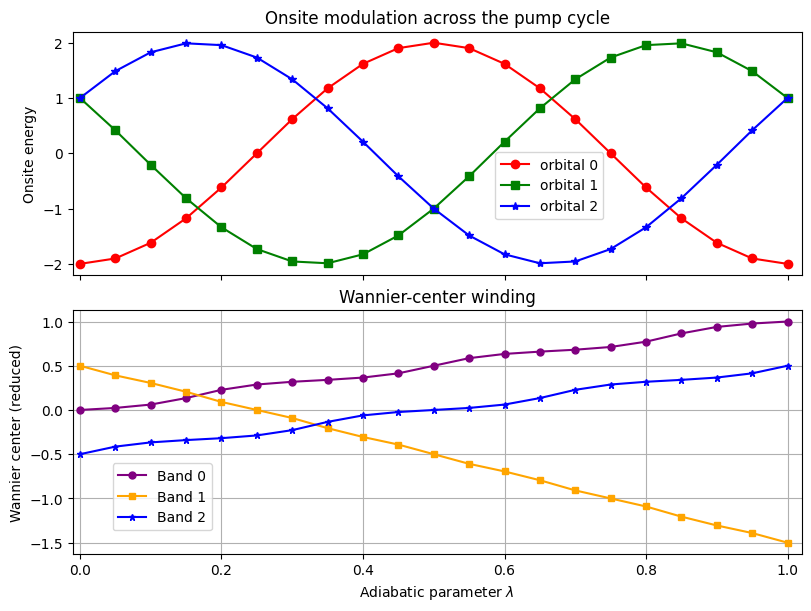

In [18]:
import matplotlib.pyplot as plt
fig, (ax_onsite, ax_wann) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, constrained_layout=True
)

all_lambda = mesh.get_param_points()[:, 0] 
onsite = np.vstack([
    delta * -np.cos(2 * np.pi * (all_lambda - shift / 3.0))
    for shift in range(3)
])

ax_onsite.plot(all_lambda, onsite[0], "ro-", label="orbital 0")
ax_onsite.plot(all_lambda, onsite[1], "gs-", label="orbital 1")
ax_onsite.plot(all_lambda, onsite[2], "b*-", label="orbital 2")

ax_onsite.set_ylabel("Onsite energy")
ax_onsite.set_title("Onsite modulation across the pump cycle")
ax_onsite.legend(bbox_to_anchor=(0.57, 0.2))

ax_wann.plot(all_lambda, wann_center0, c='purple', marker="o", ms=5, label='Band 0')
ax_wann.plot(all_lambda, wann_center1, c='orange', marker="s", ms=5, label='Band 1')
ax_wann.plot(all_lambda, wann_center2, c='b', marker="*", ms=5, label='Band 2')
ax_wann.grid()
ax_wann.legend(bbox_to_anchor=(0.2, 0.4))

ax_wann.set_xlabel(r"Adiabatic parameter $\lambda$")
ax_wann.set_ylabel("Wannier center (reduced)")
ax_wann.set_xlim(-0.01, 1.02)
ax_wann.set_title("Wannier-center winding")
plt.show()

In [19]:
U, evals = wfa.wilson_loop(0, wilson_evals=True)

/Users/treycole/Repos/pythtb/pythtb/wfarray.py:2010: ComplexWarning: Casting complex values to real discards the imaginary part
  evals[idx] = eval


In [20]:
P = wfa.projectors()  
print((P @ P)[0, 0].round(10))

[[ 1.-0.j -0.-0.j -0.-0.j]
 [-0.+0.j  1.-0.j  0.-0.j]
 [-0.+0.j  0.+0.j  1.+0.j]]
